In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import os
import joblib

df = pd.read_csv('data/cleaned_data.csv')

X = df['processed_text']
y = df['sentiment']

# Encode labels: negative=0, neutral=1, positive=2
le = LabelEncoder()
y_enc = le.fit_transform(y)

# 70% train, 20% test, 10% validation
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.667, random_state=42)

# Fit TF-IDF on training data only
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save for pipeline use later
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
joblib.dump(le,   'models/label_encoder.pkl')
print("Train:", X_train_tfidf.shape, "| Val:", X_val_tfidf.shape, "| Test:", X_test_tfidf.shape)

Train: (8796, 20000) | Val: (1255, 20000) | Test: (2516, 20000)


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import joblib

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)

print("=== Naive Bayes Results ===")
print(classification_report(y_test, nb_preds,
      target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_preds))

joblib.dump(nb_model, 'models/naive_bayes_model.pkl')
print("✓ Saved naive_bayes_model.pkl")

=== Naive Bayes Results ===
              precision    recall  f1-score   support

    negative       0.83      0.97      0.89      1326
     neutral       0.00      0.00      0.00       102
    positive       0.95      0.84      0.89      1088

    accuracy                           0.88      2516
   macro avg       0.59      0.60      0.60      2516
weighted avg       0.85      0.88      0.86      2516

Confusion Matrix:
 [[1286    1   39]
 [  95    0    7]
 [ 170    0  918]]
✓ Saved naive_bayes_model.pkl


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

MAX_WORDS = 20000
MAX_LEN   = 100
EMBED_DIM = 64

# Tokenize for LSTM (separate from TF-IDF)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_tr_seq  = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_te_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)

y_tr_cat  = to_categorical(y_train, 3)
y_val_cat = to_categorical(y_val,   3)
y_te_cat  = to_categorical(y_test,  3)

# Build LSTM model
lstm_model = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3,  activation='softmax'),
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_tr_seq, y_tr_cat, epochs=10, batch_size=64,
               validation_data=(X_val_seq, y_val_cat))

lstm_model.save('models/lstm_model.h5')
joblib.dump(tokenizer, 'models/lstm_tokenizer.pkl')
print("✓ Saved lstm_model.h5")

c:\Users\LENOVO\Documents\HPDP\Project 2\.venv_tf\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 39s 204ms/step - accuracy: 0.7492 - loss: 0.6201 - val_accuracy: 0.8821 - val_loss: 0.3571
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 196ms/step - accuracy: 0.8929 - loss: 0.3472 - val_accuracy: 0.9028 - val_loss: 0.3287
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.9196 - loss: 0.2663 - val_accuracy: 0.8948 - val_loss: 0.3412
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 189ms/step - accuracy: 0.9357 - loss: 0.2142 - val_accuracy: 0.8876 - val_loss: 0.3853
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 192ms/step - accuracy: 0.9500 - loss: 0.1752 - val_accuracy: 0.8980 - val_loss: 0.3916
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.9579 - loss: 0.1461 - val_accuracy: 0.8829 - val_loss: 0.4324
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 192ms/step - accuracy: 0.9657 - loss: 0.1229 - val_accuracy: 0.8861 - val_loss: 0.4649
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.9692 - loss: 0

✓ Saved lstm_model.h5


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step
=== NAIVE BAYES ===
              precision    recall  f1-score   support

    negative       0.83      0.97      0.89      1326
     neutral       0.00      0.00      0.00       102
    positive       0.95      0.84      0.89      1088

    accuracy                           0.88      2516
   macro avg       0.59      0.60      0.60      2516
weighted avg       0.85      0.88      0.86      2516

=== LSTM ===
              precision    recall  f1-score   support

    negative       0.86      0.87      0.86      1326
     neutral       0.12      0.07      0.09       102
    positive       0.86      0.88      0.87      1088

    accuracy                           0.84      2516
   macro avg       0.61      0.61      0.61      2516
weighted avg       0.83      0.84      0.83      2516



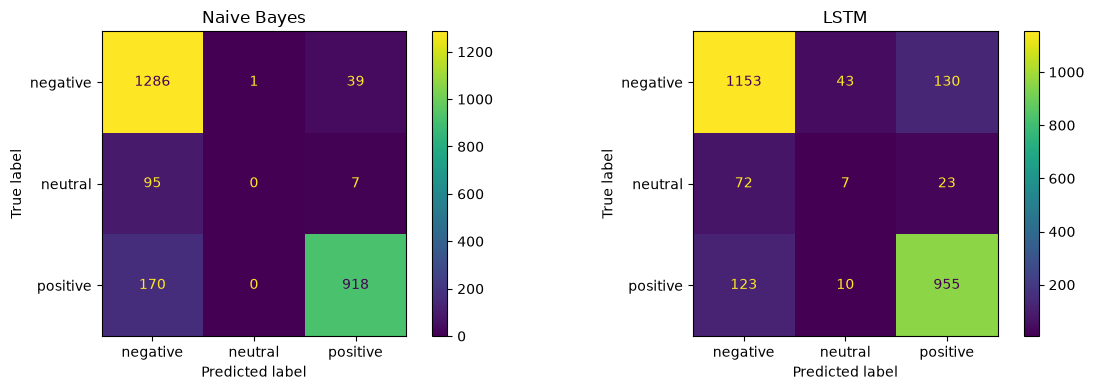

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# LSTM predictions
lstm_probs = lstm_model.predict(X_te_seq)
lstm_preds = np.argmax(lstm_probs, axis=1)

print("=== NAIVE BAYES ===")
print(classification_report(y_test, nb_preds, target_names=le.classes_))

print("=== LSTM ===")
print(classification_report(y_test, lstm_preds, target_names=le.classes_))

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes,
        [nb_preds, lstm_preds], ['Naive Bayes', 'LSTM']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=le.classes_, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.savefig('reports/confusion_matrices.png', dpi=150)
plt.show()

In [7]:
# The pipeline needs: model + vectorizer + label encoder
# Confirm these 3 files exist in models/ before handing to C:
import os
required = ['models/naive_bayes_model.pkl',
             'models/tfidf_vectorizer.pkl',
             'models/label_encoder.pkl']
for f in required:
    print(f"{'✓' if os.path.exists(f) else '✗'} {f}")

✓ models/naive_bayes_model.pkl
✓ models/tfidf_vectorizer.pkl
✓ models/label_encoder.pkl
